In [1]:
%load_ext autoreload
%autoreload 2


In [4]:
%reload_ext autoreload
import csv
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# open and parse .log file, after removing 15 header lines 
# each line after looks like: Epoch: [1/180000], mdis: 12222.005859375, the best: 12222.005859375, at 1.
log_file = "zod_20251211_093353.log"
data = []
with open(log_file, 'r') as f:
    for _ in range(15):
        next(f)  # skip header lines
    for line in f:
        parts = line.strip().split(',')
        try:
            epoch_part = int(parts[0].split('[')[1].split('/')[0])
            mdis_part = float(parts[1].split(': ')[1].strip())
            data.append((int(epoch_part), float(mdis_part)))
        except:
            continue
epochs, mdis_values = zip(*data)

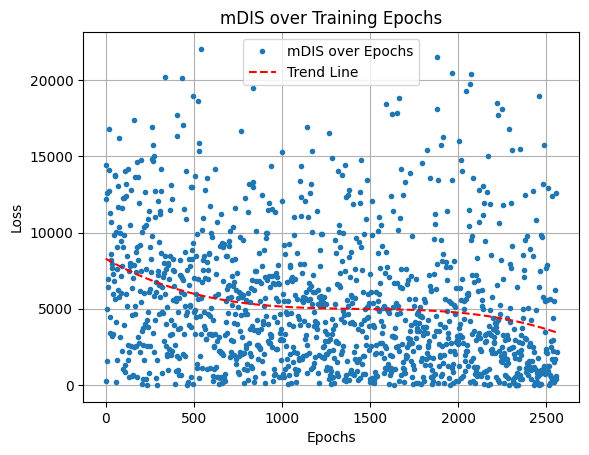

In [31]:
# plt.plot(epochs, mdis_values,label='Loss')
plt.plot(epochs, mdis_values,".",label='mDIS over Epochs')
# fit a trend line
z = np.polyfit(epochs, mdis_values,3)
p = np.poly1d(z)
plt.plot(epochs, p(epochs), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('mDIS over Training Epochs')
plt.legend()
plt.grid()
plt.show()

In [32]:
# open and parse .log file, after removing 15 header lines 
# each line after looks like: Epoch: [1/180000], mdis: 12222.005859375, the best: 12222.005859375, at 1.
log_file = "logs/log_2746423.log"
loss_list = []
RTE_l2_list = []
with open(log_file, 'r') as f:
    for _ in range(10):
        next(f)  # skip header lines
    for line in f:
        parts = line.strip().split(',')
        try:
            # epoch_part = int(parts[0].split('[')[1].split('/')[0])
            loss = float(parts[1].split(': ')[1].strip())
            RTE_l2 = float(parts[2].split(': ')[1].strip())
            # print(loss)
            loss_list.append(loss)
            RTE_l2_list.append(RTE_l2)
        except:
            continue

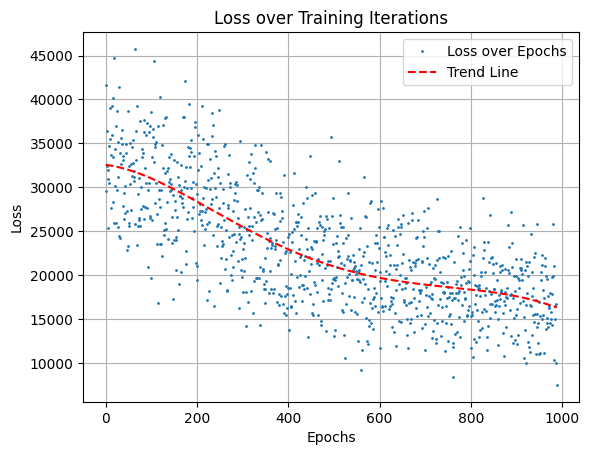

In [33]:
plt.plot(loss_list,".", markersize=2,label='Loss over Epochs')
it = list(range(len(loss_list)))
z = np.polyfit(it, loss_list,5)
p = np.poly1d(z)
plt.plot(it, p(it), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Training Iterations')
plt.legend()
plt.grid()
plt.show()

In [31]:
loss_list[:5]

[]

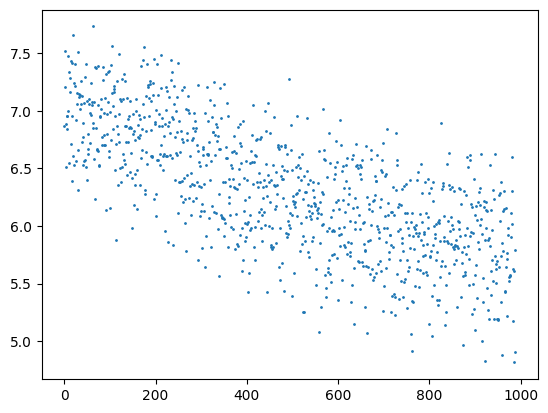

In [ ]:
plt.plot(RTE_l2_list,".", markersize=2,label='Loss over Epochs')
z = np.polyfit(it, RTE_l2_list,5)
p = np.poly1d(z)
plt.plot(it, p(it), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Training Iterations')
plt.legend()
plt.grid()
plt.show()

In [6]:
RTE_l2_list2 = np.sqrt(RTE_l2_list)
print(RTE_l2_list2[-100:].mean())
plt.plot(RTE_l2_list2,".", markersize=2,label='Loss over Epochs')

z = np.polyfit(it, RTE_l2_list2,5)
p = np.poly1d(z)
plt.plot(it, p(it), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Training Iterations')
plt.legend()
plt.grid()
plt.show()

NameError: name 'RTE_l2_list' is not defined

# 1st real training

In [10]:
fp ="metrics/train/2025_12_12_0.csv"

df = pd.read_csv(fp)
df.head()

,epoch,batch,loss,rte
0,0,0,24971.986328,45.308849
1,0,1,46214.289062,58.956730
2,0,2,32598.015625,49.203766
3,0,3,24418.972656,38.694992
4,0,4,19000.382812,38.162357


Text(0.5, 0, 'Iterations')

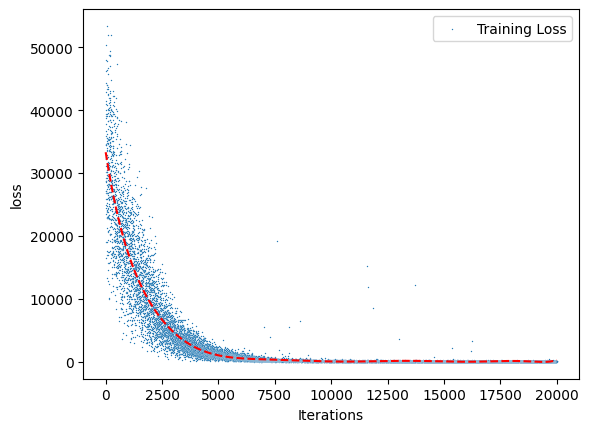

In [25]:
sns.scatterplot(data=df, x=df.index, y='loss', label='Training Loss', s=1)
# trend line
z = np.polyfit(df.index, df['loss'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')

Final 1000 mean L2 : 2.24


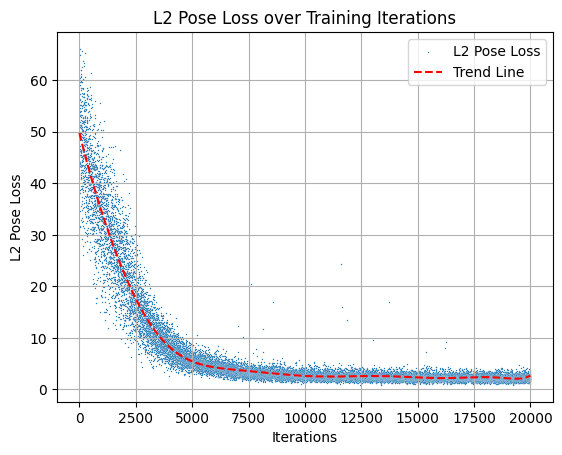

In [32]:
sns.scatterplot(data=df, x=df.index, y='rte', label='L2 Pose Loss', s=1)
# trend line
z = np.polyfit(df.index, df['rte'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('L2 Pose Loss')
plt.title('L2 Pose Loss over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean L2 : {df.rte[-1000:].mean():.2f}")


In [18]:
df.rte[-500:].mean()

2.2686761453151703

In [29]:
np.sqrt(2.268)

1.5059880477613359